## **Numerical Optimization and Large Scale Linear Algebra**

### **Assignment 2**

> Lefki Athanasopoulou
	f3352404

### **Load the Libraries**

In [130]:
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.colors as mcolors
from skimage.transform import resize
from scipy.ndimage import convolve


## **Main Part**

### **Load the data**

- `azip_df` : Training data (an array of dimension 256 x 1707 that holds the training images)
- `dzip_df` : Training data (a vector that holds the digits (the number))
- `testzip_df` : Test data (array of dimension 256 x 2007 that holds the test images)
- `dtest_df` : Test data (vector that holds the digits (the number))

In [ ]:
file_path = r'C:\Users\project_svd_handwritten\data.xlsx'
azip_df = pd.read_excel(file_path, sheet_name='azip', header=None)
dzip_df = pd.read_excel(file_path, sheet_name='dzip', header=None)
testzip_df = pd.read_excel(file_path, sheet_name='testzip', header=None)
dtest_df = pd.read_excel(file_path, sheet_name='dtest', header=None)

### **Convert the matlab function in Python**

#### The function `ima2` converts a one-dimensional (1D) numerical array into a visually interpretable 16x16 grayscale image. It adjusts the array values to fit within a specific intensity range and displays it using a custom-defined colormap.

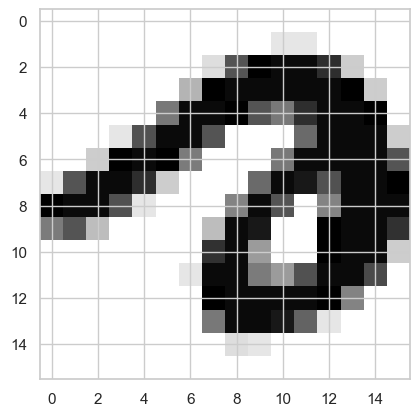

In [47]:
def ima2(A): 
	# Ensure A is a 1D array
    a1 = np.squeeze(A)
    
    # Reshape the vector into a 16x16 matrix 
    a1 = np.reshape(a1, (16, 16)).T
    
    # Translate vector to become nonnegative
    a1 = a1 - np.min(a1)
    
    # Scale to interval [0,20]
    a1 = (20 / np.max(a1)) * a1 if np.max(a1) != 0 else a1
    
    mymap1 = np.array([
        1.0000, 1.0000, 1.0000, 0.8715, 0.9028, 0.9028, 0.7431, 0.8056, 0.8056,
        0.6146, 0.7083, 0.7083, 0.4861, 0.6111, 0.6111, 0.3889, 0.4722, 0.5139,
        0.2917, 0.3333, 0.4167, 0.1944, 0.1944, 0.3194, 0.0972, 0.0972, 0.1806,
        0, 0, 0.0417
    ])
    
    cmap = ListedColormap(mymap1.reshape(-1, 1).repeat(3, axis=1))
    
    
    plt.imshow(a1, cmap=cmap , vmin=0, vmax=20) # Display the image using a colormap with a fixed intensity range [0, 20]
    plt.axis('on') # Turn axis display ON
    plt.show() # Show image


ima2(azip_df.iloc[:, 0])


#### **Create a dictionary with the Data**
Each digit (0-9) is stored in a **dictionary** where the key is the digit label (`"0"`, `"1"`, …, `"9"`) and the value is a **matrix** containing all training images of that digit.  

Each **image** is a **flattened vector** of **256 pixels** (originally from a 16×16 grid).  
Thus, for each digit, we have a **matrix of shape (256, N)** where:
- **256 rows** → each row represents a pixel position.
- **N columns** → each column is a different image of that digit.


``` json
{
    "0": [
        ["int_1", "int_2", "int_3", "...", "int_256"],
        ["int_1", "int_2", "int_3", "...", "int_256"],
        "...",
        ["int_1", "int_2", "int_3", "...", "int_256"]
    ],
    "1": [
        ["int_1", "int_2", "int_3", "...", "int_256"],
        ["int_1", "int_2", "int_3", "...", "int_256"],
        "...",
        ["int_1", "int_2", "int_3", "...", "int_256"]
    ],
    "...": "...",
    "9": [
        ["int_1", "int_2", "int_3", "...", "int_256"],
        ["int_1", "int_2", "int_3", "...", "int_256"],
        "...",
        ["int_1", "int_2", "int_3", "...", "int_256"]
    ]
}

```

In [48]:
def dictionary_format(df_digits, df_arrays):
    digits = df_digits.to_numpy().flatten()  # Convert labels to 1D NumPy array
    arrays = df_arrays.to_numpy()  # Convert images to NumPy array (256 x total images)

    # Initialize dictionary with empty lists
    dic = {i: [] for i in range(10)}

    # Assign images to corresponding digit class
    for i in range(len(digits)):
        label = digits[i]  # Get digit label (0-9)
        dic[label].append(arrays[:, i])  # Append image vector to list

    # Convert lists to NumPy arrays (so each digit class is stored as a (256, N) matrix)
    for digit in dic:
        dic[digit] = np.array(dic[digit]).T  # Transpose to get (256, N)

    return dic

---

``` json
SVD basis classification algorithm

"Training:" For the training set of known digits, compute the SVD of each set of
digits of one kind.

"Classification:" For a given test digit, compute its relative residual in all 10 bases.
If one residual is significantly smaller than all the others, classify as that.
Otherwise give up. 

```

---

#### **Training Phase**
- Compute the **Singular Value Decomposition (SVD)** for each digit class **(0–9)** separately.
- Each digit class consists of a **matrix of images**.
  - If each image is of size **\($ m \times m $\)** (e.g., 16×16 = 256 pixels), then each class is represented as a **matrix of dimension \($ m^2 \times n_i $\)**, where:
    - **\($ m^2$ \)** is the number of pixels (flattened as a vector).
    - **\( $n_i $\)** is the number of training images for that digit.
- The **first \($ k $\) singular vectors** are used to form a **basis for each class**.


---

#### **Create the `SVD` function**


- Loop over each **digit (0-9)**.
- `arrays` contain **all training images** for that digit (shape: \( $256 \times N$ \), where \($ N $\) is the number of training samples for that digit).
- **SVD decomposition:**

  \[$
  A = U \Sigma V^T$
  \]

  where:


| **Variable** | **Type** | **Size** | **Description** |
|-------------|---------|----------|----------------|
| \($ U $\) | **Matrix** | \($ (256 \times N) $\) | Left singular vectors (column basis for A) |
| \($ S $\) | **Vector (1D array)** | \($ (N,) $\) | Singular values (not a matrix, but a list of diagonal elements) |
| \($ V^T $\) | **Matrix** | \($ (N \times N) $\) | Right singular vectors (row basis for A) |




In [49]:
def svd(dataset_classes):
    svd = {}
    for digit, arrays in dataset_classes.items():
        U, S, Vt = np.linalg.svd(arrays, full_matrices=False)
        svd[digit] = (U, S, Vt)
    return svd

#### **Split in Train-Val set**

In [50]:
# Split training data into Training (80%) and Validation (20%)
train_images_full = azip_df.to_numpy().T
train_labels_full = dzip_df.to_numpy().flatten().T

train_images, val_images, train_labels, val_labels = train_test_split(
    train_images_full, train_labels_full, test_size=0.2, random_state=42, stratify=train_labels_full
)

#### **Compute the SVD of each class matrix** (training set)

In [52]:
train_classes = dictionary_format(pd.Series(train_labels), pd.DataFrame(train_images.T))
# Compute SVD basis for the training set
svd_train = svd(train_classes)

print(f'SVD matrices for digit "0": \n \n U:{svd_train[0][0]}, \n \n S: {svd_train[0][1]}, \n \n Vt: {svd_train[0][2]}')

SVD matrices for digit "0": 
 
 U:[[-9.60657537e-02 -9.41134747e-03 -1.51708232e-02 ...  3.98473886e-02
  -1.81691397e-02 -2.78971851e-02]
 [-9.58119876e-02 -9.56752148e-03 -1.50749671e-02 ... -1.70136908e-13
  -4.02017829e-14  2.63677968e-16]
 [-9.52406776e-02 -9.57496768e-03 -1.51103187e-02 ...  6.30953623e-14
   1.35638029e-14 -9.28293900e-16]
 ...
 [-9.60242633e-02 -9.27978540e-03 -1.51372821e-02 ...  1.65337796e-13
   8.47971866e-14 -4.61644611e-14]
 [-9.60657537e-02 -9.41134747e-03 -1.51708232e-02 ... -2.37195145e-01
   6.92307408e-01 -4.78212051e-01]
 [-9.60657537e-02 -9.41134747e-03 -1.51708232e-02 ...  7.96874633e-02
  -5.38517962e-01 -1.12780105e-01]], 
 
 S: [1.63415917e+02 8.95418344e+01 5.47905668e+01 4.93180455e+01
 3.72228978e+01 3.58462043e+01 3.21479721e+01 2.70309725e+01
 2.58370310e+01 2.31624542e+01 2.06133559e+01 1.84608576e+01
 1.79879878e+01 1.69800705e+01 1.66685366e+01 1.61466868e+01
 1.55215426e+01 1.47693174e+01 1.46964190e+01 1.38941285e+01
 1.29678846e+01 1

#### **Use the first few (5-20) singular vectors as basis**

#### **Function: `basis(svd_dataset, k)`**
Since the left singular vectors \($ u_i $\) from the SVD form an orthonormal basis for the column space of the matrix, we define a function called `basis`. 

**Process:**
   - A new dictionary `basis_dict` is initialized to store the **bases** for each digit class.
   - The function **loops over each digit class** in `svd_dataset`:
     - It extracts **the first \($ k $\) singular vectors** from the **left singular matrix \( $U $\)**.
     - These vectors are stored as the basis for that digit class.
   - Finally, it returns the dictionary `basis_dict`, where each digit is mapped to its **\( $256 \times k$ \) basis matrix**.


In [53]:
def basis(svd_dataset, k):
    basis_dict = {}  # Store bases for each digit class

    for label, (U, S, Vt) in svd_dataset.items():
        B = U[:, :k]  # Extract first k singular vectors
        basis_dict[label] = B  # Store it in dictionary

    return basis_dict


In [54]:
basis_10 = basis(svd_train, k=10)
basis_10

{0: array([[-0.09606575, -0.00941135, -0.01517082, ...,  0.01761361,
         -0.01364039,  0.01091119],
        [-0.09581199, -0.00956752, -0.01507497, ...,  0.01081717,
         -0.01625991,  0.00545969],
        [-0.09524068, -0.00957497, -0.01511032, ..., -0.00246969,
         -0.02339693, -0.00193595],
        ...,
        [-0.09602426, -0.00927979, -0.01513728, ...,  0.01800356,
         -0.01388406,  0.00996529],
        [-0.09606575, -0.00941135, -0.01517082, ...,  0.01761361,
         -0.01364039,  0.01091119],
        [-0.09606575, -0.00941135, -0.01517082, ...,  0.01761361,
         -0.01364039,  0.01091119]]),
 1: array([[-0.06776178, -0.00806426, -0.0041952 , ..., -0.01010649,
          0.01567312,  0.00758092],
        [-0.06776178, -0.00806426, -0.0041952 , ..., -0.01010649,
          0.01567312,  0.00758092],
        [-0.06776178, -0.00806426, -0.0041952 , ..., -0.01010649,
          0.01567312,  0.00758092],
        ...,
        [-0.06776178, -0.00806426, -0.0041952 , 

---


#### **Classification Phase**
- Given a test digit **\($ z $\)**:
  - Compute its **relative residual** in **all 10 bases** (0–9).
  - The residual is a measure of how well the digit is represented by a particular class.
  - If one residual is **significantly smaller** than all the others, classify the digit into that class.
  - Otherwise, **reject the classification**.

- The test digit \( $z$ \) is projected onto each digit's basis \($B_k $\), and the relative residual is computed:

  \[$
  \| z - B_k B_k^T z \|_2/\| z \|_2$
  \]

- The classification is made **based on the smallest residual**.

---

#### **Function: `classification_residual_vector(test_image, basis_dict)`**  

The `classification_residual_vector` function classifies a test image by computing how well it can be represented using the basis vectors of each digit class. The digit with the lowest **relative residual norm** is selected.

- **Projection**: The test image is projected onto the basis of each digit class.
- **Residual Computation**: The difference between the original test image and its projection is measured.
- **Classification**: The digit class with the smallest residual norm is selected.
 



In [55]:
def classification_residual_vector(image, basis_dict):
    min_residual = np.inf  # Initialize properly
    classified_digit = None
    
    for digit, B in basis_dict.items():
        projection = B @ (B.T @ image)
        residual_norm = np.linalg.norm(image - projection)
        relative_residual = residual_norm / np.linalg.norm(image)

        if relative_residual < min_residual:
            min_residual = relative_residual
            classified_digit = digit
    
    return classified_digit, min_residual

#### **Function: `classify_test_set`**
The `classify_test_set` function applies the residual-based classification to all test images.

- Iterates through each test image.
- Uses `classification_residual_vector` to assign a digit label.
- Stores predictions and residuals.

In [ ]:
def classify_test_set(images, basis_dict):  
    predictions = []  # List to store predicted labels for each test image
    residuals = []  # List to store residuals for each test image
    
    num_images = images.shape[1]  # Get the number of test images
    
    # Loop through each image in the test set
    for i in range(num_images):
        img = images[:, i]  # Extract the i-th test image
        # Classify the image by computing the residual and selecting the best class
        pred_label, residual = classification_residual_vector(img, basis_dict)
        
        # Store the predicted label and residual for the current image
        predictions.append(pred_label)
        residuals.append(residual)
    
    # Convert the lists of predictions and residuals to numpy arrays and return them
    return np.array(predictions), np.array(residuals)


#### **Run Classification and Evaluating Accuracy**
We apply the classification model to the test dataset using `k=10` basis vectors.

- Convert test images and labels to NumPy arrays.
- Classify the test images using `classify_test_set`.
- Compute **accuracy** using `accuracy_score`.


In [57]:
# Convert test data to NumPy array
test_images = testzip_df.to_numpy()
test_labels = dtest_df.to_numpy().flatten()

In [58]:
# Classify the test set using the previously computed basis (10 basis vectors)
predictions, residuals = classify_test_set(test_images, basis_dict=basis_10)

accuracy = accuracy_score(test_labels, predictions)
print(f'Accuracy with 10 basis vectors: {accuracy * 100:.2f}%')


Accuracy with 10 basis vectors: 92.73%



#### **Accuracy Interpretation**
- The **accuracy** of **92.73%** means that **92.73% of the test images** were correctly classified using **10 singular vectors** per digit class.

A **92.73% accuracy** with `k=10` singular vectors shows that **SVD-based classification is highly effective**, but there is room for refinement. 
The results are not good enough, as the best algorithms reach about 97% correct classifications.

---

#### 1.	Tune the algorithm for accuracy of classification. Give a table or graph of the percentage of correctly classified digits as a function of the number of basis vectors. 

---

#### Compute the accuracy based on different values of 	`k`. Specifically, find the optimal k value in [5,21], using the Validation Set.
When we **project** the training data onto the basis constructed **from the very same data**, as $k$ increases, the approximation gets better and better.

This happens because:
1. **The basis $U_k$ is derived from the same data,** so it is optimal for it.
2. **The larger $k$ is, the smaller the residual error becomes,** since the basis contains more information.
3. **With $k = \min(256, N)$, the reconstruction is perfect** (i.e., if we kept **all** the singular vectors, the training data would be reconstructed **with zero error**).


### **Conclusion**
- **If we do tuning on the training set,** we will see artificially high accuracy, but in reality the model has not generalized.
- **The proper procedure** is to choose $k$ based on a **validation or test set**, to ensure that the chosen $k$ generalizes best.

In [ ]:
def evaluate_accuracy_vs_basis(labels, images, svd_train, k_values):   
    accuracy_dict = {}  # Initialize a dictionary to store accuracy results for each k-value
    
    # Iterate over each k-value in the provided list
    for k in k_values:
        # Compute the basis for the current k-value using the svd_train
        basis_dict = basis(svd_train, k)
        
        # Classify the test set images using the computed basis and get the predictions
        predictions, _ = classify_test_set(images, basis_dict)
        
        # Compute the accuracy of the predictions by comparing with the true labels
        accuracy = accuracy_score(labels, predictions) * 100
        
        # Store the accuracy result for the current k-value
        accuracy_dict[k] = accuracy
    
    # Return the dictionary containing accuracy results for all k-values
    return accuracy_dict


In [60]:
# Define range of basis vectors to test
k_values = range(5, 21)

# Run evaluation
accuracy_results = evaluate_accuracy_vs_basis(val_labels, val_images.T, svd_train, k_values)

In [61]:
# Save predictions and accuracy in a DataFrame
results_df = pd.DataFrame({"k": list(accuracy_results.keys()), 
                           "Accuracy (%)": list(accuracy_results.values())})


In [62]:
# Convert accuracy results into a DataFrame
accuracy_df = pd.DataFrame(list(accuracy_results.items()), columns=["Number of Singular Vectors (k)", "Classification Accuracy (%)"]).round(2)
accuracy_df.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
Number of Singular Vectors (k),5.0,6.0,7.00,8.00,9.00,10.00,11.00,12.00,13.00,14.00,15.00,16.0,17.00,18.0,19.0,20.00
Classification Accuracy (%),96.2,96.2,95.61,97.37,96.78,97.37,96.78,97.08,97.95,96.78,96.78,96.2,96.49,96.2,96.2,96.49


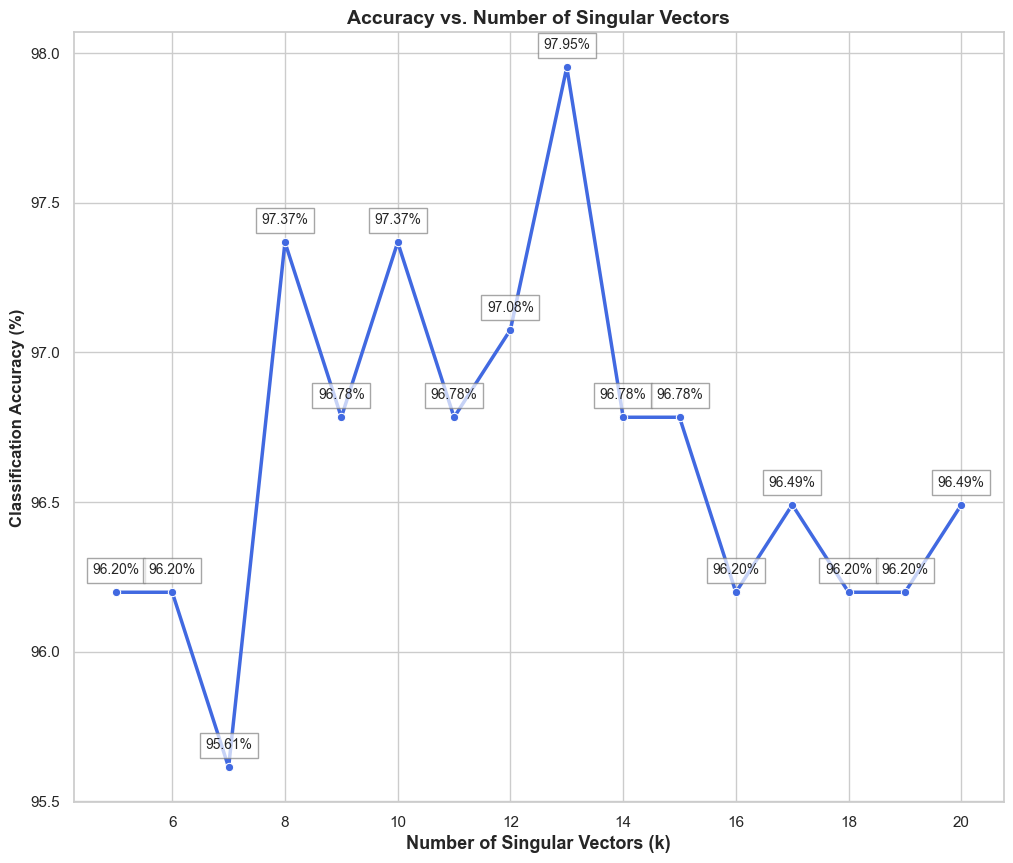

In [63]:
# Set Seaborn style 
sns.set_theme(style="whitegrid")

# Create a figure and axis
plt.figure(figsize=(12, 10))

# Plot accuracy vs. k with a smooth line and markers
sns.lineplot(x=list(accuracy_results.keys()), 
             y=list(accuracy_results.values()), 
             marker="o", linewidth=2.5, color="royalblue")

# Enhance labels and title
plt.xlabel("Number of Singular Vectors (k)", fontsize=13, fontweight='bold')
plt.ylabel("Classification Accuracy (%)", fontsize=12, fontweight='bold')
plt.title("Accuracy vs. Number of Singular Vectors", fontsize=14, fontweight='bold')

# # Clearly annotate accuracy points without overlap
for idx, row in results_df.iterrows():
    plt.text(row["k"], row["Accuracy (%)"] + 0.05, f"{row['Accuracy (%)']:.2f}%", 
             fontsize=10, ha='center', va='bottom', 
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))
# Display the plot
plt.show()


In [64]:
# Find the best k (highest accuracy) of validation set
best_k = max(accuracy_results, key=accuracy_results.get)
best_predictions = accuracy_results[best_k]

print(f"\nBest k value: {best_k} with accuracy {accuracy_results[best_k]:.2f}%")



Best k value: 13 with accuracy 97.95%


In [65]:
# Compute final basis using the best k from training
final_basis = basis(svd_train, best_k)

# Classify test set using the best k
test_images = testzip_df.to_numpy()
test_labels = dtest_df.to_numpy().flatten()
predictions, residuals = classify_test_set(test_images, final_basis)

# Compute test accuracy
final_accuracy = accuracy_score(test_labels, predictions) * 100
print(f"Final Test Accuracy using best k={best_k}: {final_accuracy:.2f}%")


Final Test Accuracy using best k=13: 93.42%


---

#### 2. Check if all digits are equally easy or difficult to classify. Also look at some of the difficult ones, and see that in many cases they are very badly written

---

### **Analysis of Digit Classification Performance**

#### **Digits that are Easy to Classify (High Recall & Precision):**  
- **Digit 0**: Achieves a high recall of **98.61%** and strong precision of **94.40%**, making it one of the easiest digits to classify.  
- **Digit 1**: Exhibits excellent recall (**98.48%**) and precision (**96.65%**), indicating minimal confusion with other digits.  
- **Digit 6**: Stands out with **94.12% recall** and **95.81% precision**, showing a strong ability to be correctly identified.  



#### **Digits that are Harder to Classify (Lower Recall & Precision):**  
- **Digit 5**: The most challenging digit, with the lowest recall (**86.25%**), meaning it is frequently misclassified.  
- **Digit 3**: Struggles with a **recall of 87.95%** and precision of **88.48%**, often mistaken for other similar-looking digits.  
- **Digit 4**: Shows moderate recall (**92.00%**) and precision (**91.54%**), indicating that some instances are confused with other numbers.  



#### **Insights from the Confusion Matrix:**  
- **Digit 5** is often confused with **3 and 9**, with **11 instances of misclassification into digit 3**.  
- **Digit 3** has notable confusion, particularly with **digit 4 (10 occurrences)** and **digit 5 (11 occurrences)**.  
- **Digit 2** is commonly mistaken for **digit 0 (8 occurrences)**, possibly due to similarities in handwriting styles.  
- **Digit 4** is misclassified as **digit 9 (7 occurrences)**, likely due to the visual resemblance in some handwritten samples.  
- **Digit 9** is misclassified as **digit 4 (5 occurrences)**, reinforcing the idea that these digits are sometimes hard to distinguish in messy handwriting.  



### **Conclusion:**  
- **Digits 0, 1, and 6 are the easiest to classify** with high recall and precision.  
- **Digits 3, 4, and 5 show the most confusion**, often mistaken for visually similar digits.  


In [66]:
# Using best_k found from previous step
basis_best = basis(svd_train, best_k)

# Predict using the best basis
predictions, residuals = classify_test_set(testzip_df.to_numpy(), basis_best)

# Get confusion matrix
cm = confusion_matrix(test_labels, predictions, labels=range(10))

# Generate classification report
report = classification_report(test_labels, predictions, digits=4)
print(report)

              precision    recall  f1-score   support

           0     0.9440    0.9861    0.9646       359
           1     0.9665    0.9848    0.9756       264
           2     0.9519    0.8990    0.9247       198
           3     0.8848    0.8795    0.8822       166
           4     0.9154    0.9200    0.9177       200
           5     0.9020    0.8625    0.8818       160
           6     0.9581    0.9412    0.9496       170
           7     0.9333    0.9524    0.9428       147
           8     0.9434    0.9036    0.9231       166
           9     0.9116    0.9322    0.9218       177

    accuracy                         0.9342      2007
   macro avg     0.9311    0.9261    0.9284      2007
weighted avg     0.9342    0.9342    0.9339      2007



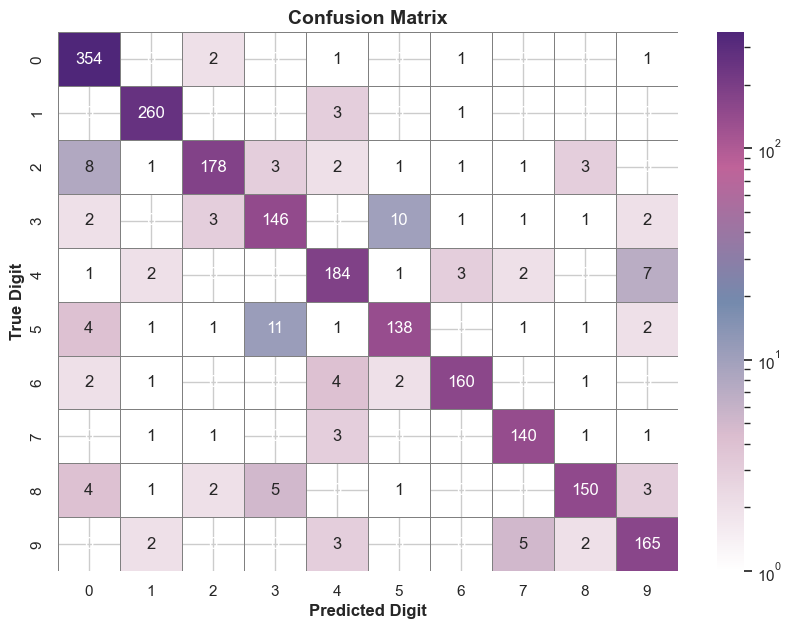

In [67]:
plt.figure(figsize=(10, 7))

# Logarithmic normalization (clearly highlights small numbers)
log_norm = mcolors.LogNorm(vmin=1, vmax=cm.max())

# Define custom colormap clearly
colors = ["#ffffff", "#dbbdcf", "#748aad", "#bf6399", "#4f2679"]
cmap = mcolors.LinearSegmentedColormap.from_list("distinct_cmap", colors)

sns.heatmap(cm, annot=True, cmap=cmap, norm=log_norm, fmt='d', linewidths=0.5, linecolor='gray')

plt.xlabel('Predicted Digit', fontsize=12, fontweight='bold')
plt.ylabel('True Digit', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')

plt.show()

Total misclassified digits: 132
True Digit: 6, Predicted: 0


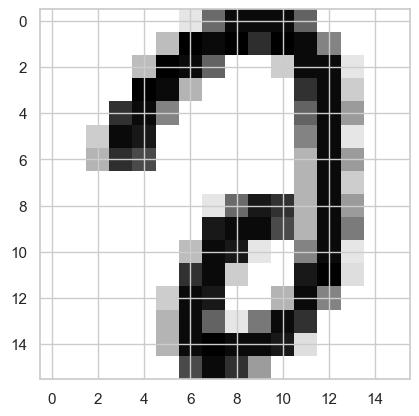

True Digit: 2, Predicted: 3


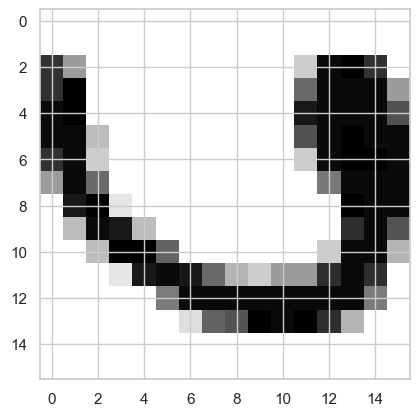

True Digit: 6, Predicted: 4


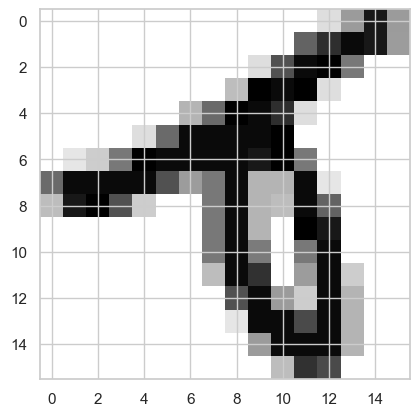

True Digit: 5, Predicted: 3


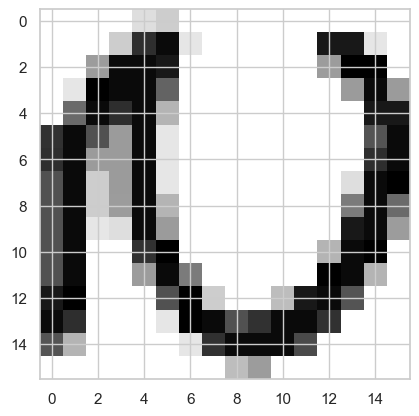

True Digit: 2, Predicted: 0


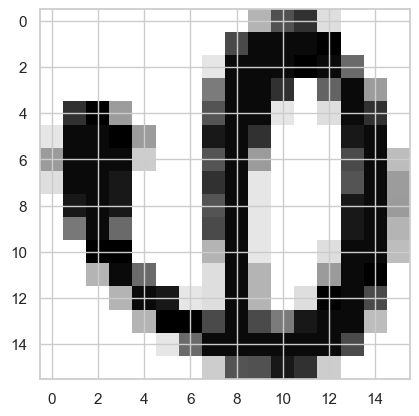

True Digit: 8, Predicted: 3


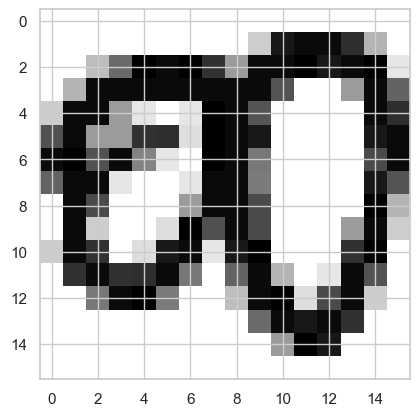

True Digit: 3, Predicted: 7


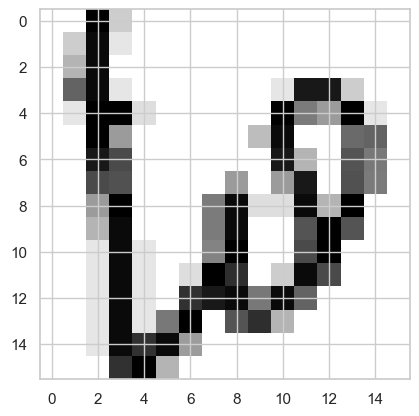

True Digit: 6, Predicted: 4


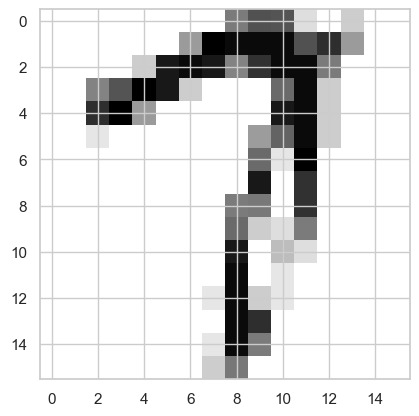

True Digit: 9, Predicted: 7


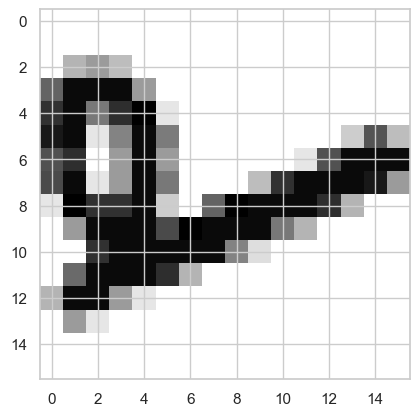

True Digit: 2, Predicted: 0


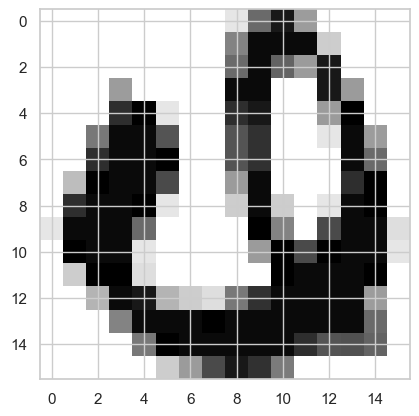

In [68]:
# Find misclassified examples
misclassified_indices = np.where(predictions != test_labels)[0]

print(f"Total misclassified digits: {len(misclassified_indices)}")

# Clearly visualize first 10 misclassified digits
num_samples_to_show = 10

for idx in misclassified_indices[:num_samples_to_show]:
    print(f"True Digit: {test_labels[idx]}, Predicted: {predictions[idx]}")
    ima2(testzip_df.iloc[:, idx])

---

#### 3	Check the singular values of the different classes. Is it motivated to use different numbers of basis vectors for different classes? If so, perform a few experiments to find out if it really pays off to use fewer basis vectors in one or two of the classes. 

---

This code **plots the first \($k$\) singular values** for each digit class side by side, in order tp **compare how quickly the singular values decay** for different digits.

1. **Singular Value Decomposition (SVD)**:  
   - For each digit class, we already computed \( $U, S, V^T$ \), where \($S$ \) contains the singular values in **descending order**.  
   - The **larger** a singular value, the **more variance** (or "information") it captures about the images in that digit class.

2. **Plotting the First \($k$\) Singular Values**:
   - `S[:k]` means we’re only taking the **top \($k$\)** singular values (the most significant ones).  
   - Each line on the plot corresponds to a **digit class** (0–9).

3. **What we Learn**:
   - **How quickly the singular values drop off** for each digit class.  
   - If a digit's line **drops quickly**, we can often use **fewer** basis vectors without losing much information.  
   - If it **drops more slowly**, we might need **more** basis vectors to represent that digit accurately.

4. **Why This Matters**:
   - **Faster Decay** → we can **lower \($k$\)** for that digit, saving computation and still maintaining good accuracy.  
   - **Slower Decay** → we might need a **larger \($k$\)** to accurately classify that digit.

5. **Digits That Seem To Have a Quick Drop**
   - Digit 1
   - Digit 7



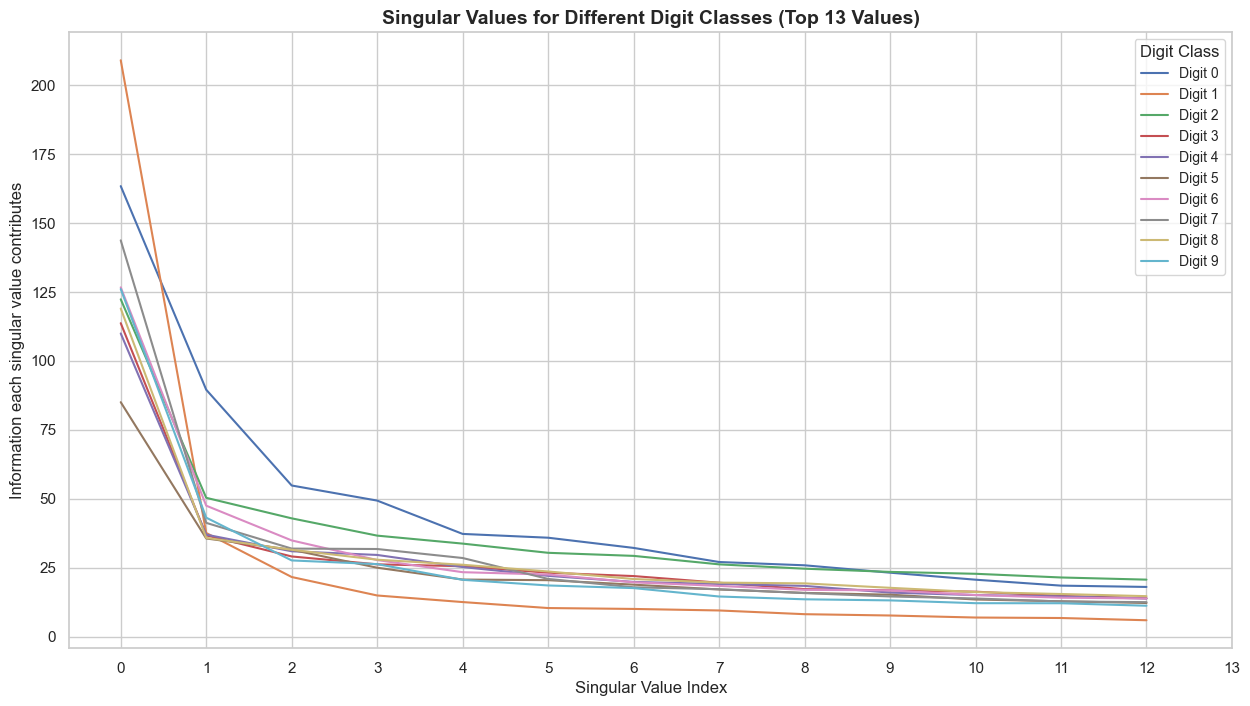

In [69]:
# Define k (number of singular values to display)
k = best_k  

plt.figure(figsize=(15, 8))

# Loop through each digit class and plot only the first k singular values
for digit, (U, S, Vt) in svd_train.items():
    plt.plot(S[:k], label=f"Digit {digit}")  # Only take the first k singular values

# Customize plot with more x-axis ticks
plt.xticks(range(0, k + 1, max(1, k // 10)))  # Set x-axis ticks dynamically
plt.xlabel("Singular Value Index", fontsize=12)
plt.ylabel("Information each singular value contributes", fontsize=12)
plt.title(f"Singular Values for Different Digit Classes (Top {k} Values)", fontsize=14, fontweight="bold")
plt.legend(title="Digit Class", fontsize=10)
plt.grid(True)

# Show the plot
plt.show()

In [70]:
def basis_with_custom_k(svd_dataset, k_values_dict):
    basis_dict = {}  # Store bases for each digit class

    for label, (U, S, Vt) in svd_dataset.items():
        k = k_values_dict.get(label, best_k)  
        B = U[:, :k]  # Extract first k singular vectors
        basis_dict[label] = B  # Store it in dictionary

    return basis_dict

In [109]:
# Function to test different k-values for custom digits
def iterate_custom_k_values(svd_dataset, k_values_dict, val_images, val_labels):
    results = {}
    
    # Iterate over all possible combinations of k values for digit 1 and 7
    for k_1 in k_values_dict['1']:
        for k_7 in k_values_dict['7']:
            k_values = {1: k_1, 7: k_7}
            basis_custom_k = basis_with_custom_k(svd_dataset, k_values)
            
            # Classify the test set using these custom k-values
            predictions, residuals = classify_test_set(val_images.T, basis_custom_k)
            
            # Compute accuracy
            accuracy = accuracy_score(val_labels, predictions)
            results[(k_1, k_7)] = accuracy * 100  # Store accuracy for the current combination of k-values
            
    return results

# Define a range of k-values to test for digits 1 and 7
k_values_dict = {
    '1': [best_k-5, best_k-3, best_k-1],  
    '7': [best_k-5, best_k-3, best_k-1]   
}

# Apply the function to iterate over the k-values
svd_train = svd(dictionary_format(pd.Series(train_labels), pd.DataFrame(train_images.T)))
results = iterate_custom_k_values(svd_train, k_values_dict, val_images, val_labels)

# Print the results (accuracy for different k-values)
for (k_1, k_7), accuracy in results.items():
    print(f"Accuracy with k=(k_1: {k_1}, k_7: {k_7}) : {accuracy:.2f}%")

Accuracy with k=(k_1: 8, k_7: 8) : 97.37%
Accuracy with k=(k_1: 8, k_7: 10) : 97.95%
Accuracy with k=(k_1: 8, k_7: 12) : 97.95%
Accuracy with k=(k_1: 10, k_7: 8) : 97.37%
Accuracy with k=(k_1: 10, k_7: 10) : 97.95%
Accuracy with k=(k_1: 10, k_7: 12) : 97.95%
Accuracy with k=(k_1: 12, k_7: 8) : 97.37%
Accuracy with k=(k_1: 12, k_7: 10) : 97.95%
Accuracy with k=(k_1: 12, k_7: 12) : 97.95%


In [110]:
# Find the best k-values for digits 1 and 7 based on the highest accuracy from the validation set
best_k_1, best_k_7 = max(results, key=results.get)

print(f"Best k-values: k for Digit 1 = {best_k_1}, k for Digit 7 = {best_k_7}")

# Now, we can compute the final basis using these best k-values
k_values = {1: best_k_1, 7: best_k_7}
basis_custom_k = basis_with_custom_k(svd_train, k_values)

# Classify the test set using the best k-values
test_predictions, test_residuals = classify_test_set(test_images, basis_custom_k)

# Compute test accuracy
test_accuracy = accuracy_score(test_labels, test_predictions)
print(f"Test Accuracy using best k-values: {test_accuracy * 100:.2f}%")

Best k-values: k for Digit 1 = 8, k for Digit 7 = 10
Test Accuracy using best k-values: 93.47%


In [111]:
print("\nClassification Report:")
print(classification_report(test_labels, test_predictions, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     0.9440    0.9861    0.9646       359
           1     0.9923    0.9811    0.9867       264
           2     0.9519    0.8990    0.9247       198
           3     0.8848    0.8795    0.8822       166
           4     0.8976    0.9200    0.9086       200
           5     0.9032    0.8750    0.8889       160
           6     0.9471    0.9471    0.9471       170
           7     0.9645    0.9252    0.9444       147
           8     0.9379    0.9096    0.9235       166
           9     0.8930    0.9435    0.9176       177

    accuracy                         0.9347      2007
   macro avg     0.9316    0.9266    0.9288      2007
weighted avg     0.9351    0.9347    0.9346      2007



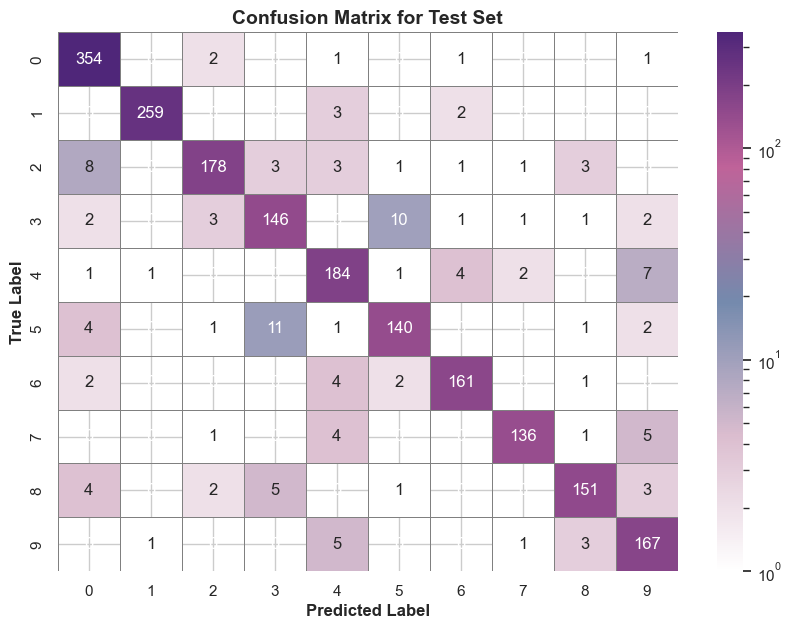

In [101]:
cm = confusion_matrix(dtest_df.to_numpy().flatten(), test_predictions)
plt.figure(figsize=(10, 7))

# Logarithmic normalization (clearly highlights small numbers)
log_norm = mcolors.LogNorm(vmin=1, vmax=cm.max())

# Define custom colormap clearly
colors = ["#ffffff", "#dbbdcf", "#748aad", "#bf6399", "#4f2679"]
cmap = mcolors.LinearSegmentedColormap.from_list("distinct_cmap", colors)

sns.heatmap(cm, annot=True, cmap=cmap, norm=log_norm, fmt='d', linewidths=0.5, linecolor='gray')
plt.xlabel("Predicted Label", fontsize=12, fontweight='bold')
plt.ylabel("True Label", fontsize=12, fontweight='bold')
plt.title("Confusion Matrix for Test Set", fontsize=14, fontweight='bold')
plt.show()

### **Conclusion**

After observing that different digits exhibit **distinct decay rates** in their singular values, we hypothesized that **using fewer basis vectors (k) for certain classes** might improve classification efficiency or even accuracy. In particular, digits with **steeply falling singular values** (e.g., **digit 1** and **digit 7**) likely don't need as many vectors to capture most of their structure.

### **Steps Performed**
1. **Singular Value Analysis**  
   - Plotted the **top 13 singular values** for each digit class.
   - Identified classes with **faster decay** (digits 1 & 7) as candidates for **reduced k**.

2. **Per-Class k Tuning**  
   - Kept **k = 13** for all other digits (the baseline choice).
   - For **digit 1**, experimented with **k = 8**.
   - For **digit 7**, experimented with **k = 10**.
   - Measured **test accuracy** after applying these custom k-values.

3. **Comparison to Baseline**  
   - **Baseline (k = 13 for all)**: 93.42% accuracy.
   - **Customized (k=8 for digit 1, k=10 for digit 7)**: 93.47% accuracy.

### **Results**
- **Accuracy** improved slightly from **93.42% → 93.47%**.
- **Digit 1** showed increased precision and recall, suggesting **fewer vectors** retained enough information while filtering out noise.
- **Digit 7** maintained strong performance at a slightly lower k.

### **Insights**
- Although the overall improvement was modest (+0.05%), certain digits clearly benefited (e.g., digit 1).
- If a digit’s singular values drop rapidly, reducing k can preserve accuracy while potentially lowering computation.



---

---

### **Optional Tasks**

---

### **TWO-STAGE ALGORITHM WITH SVD**
In order to save operations in the test phase, implement a two-stage algorithm: In the first stage compare the unknown digit only to the first singular vector in each class. If for one class the residual is significantly smaller than for the others, classify as that class. Otherwise perform the algorithm above. Is it possible to get as good results for this variant? How frequently is the second stage unnecessary?


---

### **Implementation Overview**
To optimize computational efficiency during the test phase, we implemented a **two-stage classification algorithm**:

1. **Stage 1 (Fast Approximation):**  
   - The unknown digit is compared only to the **first singular vector (k=1)** of each class.  
   - If one class has a significantly smaller residual than the others (based on a ratio threshold), the digit is immediately classified.  

2. **Stage 2 (Full Classification):**  
   - If Stage 1 is inconclusive, the classification proceeds with **full basis vectors (best k for each digit)** as in the original approach.  



In [121]:
def get_per_class_k():
    per_class_k = {}
    for digit in range(10):
        if digit == 1:
            per_class_k[digit] = 8
        elif digit == 7:
            per_class_k[digit] = 10
        else:
            per_class_k[digit] = 13
    return per_class_k

# Example usage:
best_k_values = get_per_class_k()
print("Initialized best k-values per digit:", best_k_values)


Initialized best k-values per digit: {0: 13, 1: 8, 2: 13, 3: 13, 4: 13, 5: 13, 6: 13, 7: 10, 8: 13, 9: 13}


In [122]:
def classify_digit_two_stage(test_image, svd_train, basis_full):

    # Stage 1: Compute residuals using only the first singular vector for each digit
    residuals_stage1 = {}
    for digit, (U, S, Vt) in svd_train.items():
        B1 = U[:, :1]  # Use only the first singular vector
        projection = B1 @ (B1.T @ test_image)
        residual = np.linalg.norm(test_image - projection) / np.linalg.norm(test_image)
        residuals_stage1[digit] = residual

    # Find the two smallest residuals
    sorted_digits = sorted(residuals_stage1, key=lambda d: residuals_stage1[d])
    min_digit = sorted_digits[0]
    min_residual = residuals_stage1[min_digit]
    second_min_residual = residuals_stage1[sorted_digits[1]]

    # Compute dynamic threshold as the ratio of the two smallest residuals
    dynamic_threshold = second_min_residual / min_residual if min_residual > 0 else np.inf

    if dynamic_threshold >= 1.3:  # Example threshold value, can be tuned
        return min_digit, min_residual, True  # Stage 1 classification
    
    # Stage 2: Use full basis (best_k singular vectors)
    residuals_full = {}
    for digit, B in basis_full.items():
        projection = B @ (B.T @ test_image)
        residual = np.linalg.norm(test_image - projection) / np.linalg.norm(test_image)
        residuals_full[digit] = residual

    best_digit = min(residuals_full, key=residuals_full.get)
    return best_digit, residuals_full[best_digit], False  # Stage 2 classification


#### **Function:** `classify_test_set_two_stage`:
Applies the two-stage classification to all test images.
    
Returns:
   - predictions: array of predicted digit labels,
   - residuals: array of corresponding residuals,
   - stage1_count: number of images classified in Stage 1.


In [ ]:
def classify_test_set_two_stage(images, svd_train, basis_full):

    predictions = []  # List to store predicted labels for each image
    residuals = []  # List to store residuals for each test image
    stage1_count = 0  # Counter for how many images were classified in Stage 1
    
    # Loop through each image in the test set
    for i in range(images.shape[1]):
        img = images[:, i]  # Extract the current test image
        # Perform two-stage classification for the current image
        pred_digit, res, stage1_used = classify_digit_two_stage(img, svd_train, basis_full)
        
        # Append the prediction and residual to the lists
        predictions.append(pred_digit)
        residuals.append(res)
        
        # If Stage 1 was sufficient, increment the counter
        if stage1_used:
            stage1_count += 1
            
    # Convert predictions and residuals lists into numpy arrays and return the results
    return np.array(predictions), np.array(residuals), stage1_count


In [ ]:
def basis_with_custom_k(svd_train, per_class_k):
    basis_dict = {}
    for digit, (U, S, Vt) in svd_train.items():
        k = per_class_k[digit]  # e.g., 8 for digit 1, 10 for digit 7, 13 otherwise
        basis_dict[digit] = U[:, :k]
    return basis_dict


In [ ]:
# Compute the full basis using the optimal uniform k from validation:
basis_full = basis_with_custom_k(svd_train, best_k_values)

# Classify the test set using the two-stage algorithm:
predictions_two_stage, residuals_two_stage, stage1_count = classify_test_set_two_stage(test_images, svd_train, basis_full)

# Compute the test accuracy:
test_accuracy_two_stage = accuracy_score(test_labels, predictions_two_stage) * 100
print(f"Test Accuracy (Two-Stage): {test_accuracy_two_stage:.2f}%")
print(f"Stage 1 was sufficient for {stage1_count} out of {test_images.shape[1]} test images.")


Test Accuracy (Two-Stage): 93.47%
Stage 1 was sufficient for 616 out of 2007 test images.


In [128]:
# Print a classification report 
print("\nClassification Report (Two-Stage):")
print(classification_report(test_labels, predictions_two_stage, digits=4))


Classification Report (Two-Stage):
              precision    recall  f1-score   support

           0     0.9440    0.9861    0.9646       359
           1     0.9885    0.9811    0.9848       264
           2     0.9519    0.8990    0.9247       198
           3     0.8848    0.8795    0.8822       166
           4     0.9020    0.9200    0.9109       200
           5     0.9032    0.8750    0.8889       160
           6     0.9471    0.9471    0.9471       170
           7     0.9645    0.9252    0.9444       147
           8     0.9379    0.9096    0.9235       166
           9     0.8930    0.9435    0.9176       177

    accuracy                         0.9347      2007
   macro avg     0.9317    0.9266    0.9289      2007
weighted avg     0.9351    0.9347    0.9346      2007



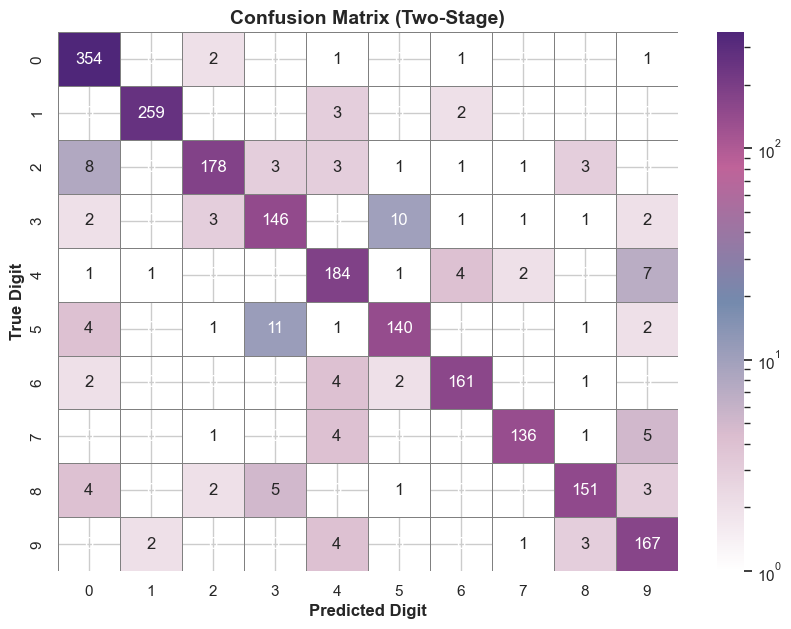

In [129]:
# Plot confusion matrix
cm = confusion_matrix(test_labels, predictions_two_stage, labels=range(10))
plt.figure(figsize=(10, 7))
log_norm = mcolors.LogNorm(vmin=1, vmax=cm.max())
# Define custom colormap clearly
colors = ["#ffffff", "#dbbdcf", "#748aad", "#bf6399", "#4f2679"]
cmap = mcolors.LinearSegmentedColormap.from_list("distinct_cmap", colors)

sns.heatmap(cm, annot=True, cmap=cmap, norm=log_norm, fmt='d', linewidths=0.5, linecolor='gray')
plt.xlabel("Predicted Digit", fontsize=12, fontweight='bold')
plt.ylabel("True Digit", fontsize=12, fontweight='bold')
plt.title("Confusion Matrix (Two-Stage)", fontsize=14, fontweight='bold')
plt.show()


### **Comparison**

### **Results & Observations**

### **Is It Possible to Get the Same Results?**
- **Yes**, the two-stage algorithm achieves the **same test accuracy** (93.47%) as the standard approach.  
- **Precision, recall, and misclassification patterns remain identical**, meaning the performance is not affected.  

However, the major advantage is that **30.7% of test images were classified without requiring full SVD computations**, making the process more **efficient** without sacrificing accuracy.  



### **How Frequently is the Second Stage Unnecessary?**
**Stage 1 successfully classified 616 out of 2007 images** (~30.7%).  
**The remaining 69.3% required full classification in Stage 2**.

This suggests that a **significant portion of images can be classified with minimal computation**, reducing the overall processing cost.


### **Conclusion**
- If the goal is **higher efficiency** (faster classification), the **two-stage approach is beneficial**, as **one-third of test images are classified instantly**.
- If the goal is **improving accuracy**, this method **does not provide any additional benefits**, and keeping the standard approach is equally effective.



---

### **Tangeant Distance**

---

#### **Resize images to $20\times 20 $**

#### `ima2`: Convert a 1D numerical array (expected size 256, representing a 16x16 image) into a visually interpretable 20x20 grayscale image. The vector values are shifted to be nonnegative, scaled to [0, 20], resized to 20x20, and displayed using a custom colormap.


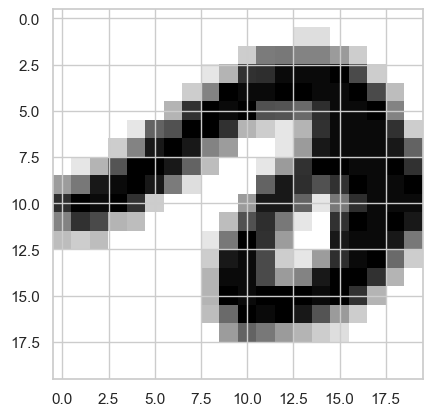

In [ ]:
def ima2(A):
    a1 = np.squeeze(A)
    # Reshape into 16x16 and transpose
    a1 = np.reshape(a1, (16, 16)).T
    a1 = a1 - np.min(a1)
    if np.max(a1) != 0:
        a1 = (20 / np.max(a1)) * a1
    # Resize to 20x20
    a1_resized = resize(a1, (20, 20), mode='reflect', anti_aliasing=True)
    if np.max(a1_resized) != 0:
        a1_resized = (20 / np.max(a1_resized)) * a1_resized
    mymap1 = np.array([
        1.0000, 1.0000, 1.0000, 0.8715, 0.9028, 0.9028, 0.7431, 0.8056, 0.8056,
        0.6146, 0.7083, 0.7083, 0.4861, 0.6111, 0.6111, 0.3889, 0.4722, 0.5139,
        0.2917, 0.3333, 0.4167, 0.1944, 0.1944, 0.3194, 0.0972, 0.0972, 0.1806,
        0, 0, 0.0417
    ])
    cmap = ListedColormap(mymap1.reshape(-1, 1).repeat(3, axis=1))
    plt.imshow(a1_resized, cmap=cmap, vmin=0, vmax=20)
    plt.axis('on')
    plt.show()

ima2(azip_df.iloc[:, 0])


#### `resize_image`: Similar to ima2 but returns the resized image (as a 2D array). Input A is a 256-dim vector (from a 16x16 image). Returns a resized (20x20) image.


In [ ]:
def resize_image(A, new_size=(20, 20)):
    a1 = np.squeeze(A)
    a1 = np.reshape(a1, (16, 16)).T
    a1 = a1 - np.min(a1)
    if np.max(a1) != 0:
        a1 = (20 / np.max(a1)) * a1
    a1_resized = resize(a1, new_size, mode='reflect', anti_aliasing=True)
    if np.max(a1_resized) != 0:
        a1_resized = (20 / np.max(a1_resized)) * a1_resized
    return a1_resized


#### `compute_derivatives`: Given a flattened image vector, reshape it into an m x m image and compute its finite difference approximations for x- and y-derivatives. Returns p_x and p_y as m x m arrays.


In [ ]:
# Tangent Distance Classification Functions (using resized images)

def compute_derivatives(image, m=20):
    img = image.reshape((m, m))
    kernel_x = np.array([[-1, 1]])
    kernel_y = np.array([[-1], [1]])
    p_x = convolve(img, kernel_x, mode='nearest')
    p_y = convolve(img, kernel_y, mode='nearest')
    return p_x, p_y


#### `compute_tangent_matrix`: Compute the tangent matrix T for a given image. The image is expected as a flattened vector which is first resized to m x m. Returns T of shape (m*m, 7) where each column is the flattened derivative for one transformation.


In [ ]:

def compute_tangent_matrix(image, m=20):
    # Resize the image using the helper function
    img_resized = resize_image(image, new_size=(m, m))
    # Compute derivatives
    p_x, p_y = compute_derivatives(img_resized, m)
    
    # Create coordinate grids and center them (for rotation/scaling)
    x_coords, y_coords = np.meshgrid(np.arange(m), np.arange(m))
    x_centered = x_coords - (m - 1) / 2.0
    y_centered = y_coords - (m - 1) / 2.0
    
    # Compute derivative images for the 7 transformations:
    T_x = p_x                                         # Translation in x
    T_y = p_y                                         # Translation in y
    T_rot = y_centered * p_x - x_centered * p_y       # Rotation derivative
    T_scaling = x_centered * p_x + y_centered * p_y     # Scaling derivative
    T_par = x_centered * p_x - y_centered * p_y         # Parallel hyperbolic transformation
    T_diag = y_centered * p_x + x_centered * p_y        # Diagonal hyperbolic transformation
    T_thick = p_x**2 + p_y**2                           # Thickening derivative (simple variant)
    
    # Flatten each derivative image to a vector of length m*m
    T_x_vec = T_x.flatten()
    T_y_vec = T_y.flatten()
    T_rot_vec = T_rot.flatten()
    T_scaling_vec = T_scaling.flatten()
    T_par_vec = T_par.flatten()
    T_diag_vec = T_diag.flatten()
    T_thick_vec = T_thick.flatten()
    
    T = np.column_stack((T_x_vec, T_y_vec, T_rot_vec, T_scaling_vec, T_par_vec, T_diag_vec, T_thick_vec))
    return T


#### `tangent_distance`:Compute the tangent distance between two images p and e. Both p and e are flattened vectors (originally 256-d, but here we resize to m*m). The tangent distance is the minimal residual from solving:
$min_{alpha} || (p - e) - (T_p*alpha_p - T_e*alpha_e) ||_2.$


In [ ]:
def tangent_distance(p, e, m=20):

    # Resize both images to m x m and flatten them
    # Resizing ensures the images are in the same size and shape
    p_resized = resize_image(p, new_size=(m, m)).flatten()  # Resize and flatten image p
    e_resized = resize_image(e, new_size=(m, m)).flatten()  # Resize and flatten image e
    
    # Compute the tangent matrix for both images
    T_p = compute_tangent_matrix(p, m)  # Tangent matrix for the first image (p)
    T_e = compute_tangent_matrix(e, m)  # Tangent matrix for the second image (e)
    
    # Create the A matrix (combines the two tangent matrices)
    # A is a matrix of shape (m*m, 14) that contains both tangent matrices side by side
    A = np.hstack((T_p, -T_e))  # Combining the tangent matrices
    
    # Calculate the difference between the resized images
    b = p_resized - e_resized  # This is the vector of differences between the two images
    
    # Solve the least-squares problem to find alpha
    # `alpha` is the set of coefficients that best minimize the error
    alpha, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)
    
    # Calculate the residual or distance
    # If the residuals array has values, take the first value as the distance
    if residuals.size > 0:
        dist = np.sqrt(residuals[0])  # Take the square root of the residual to get the distance
    else:
        dist = np.linalg.norm(b - A @ alpha)  # If no residuals are provided, use the norm of the error
    
    return dist


#### `classify_with_tangent_distance`: 
#### Classify each test image (flattened vector) by comparing its tangent distance to every training image.
- test_images: array of shape (256, N_test)
- train_images: array of shape (256, N_train)
- train_labels: 1D array (length N_train)
- m: target image dimension (m x m)
Returns predicted labels and the list of minimal distances.


In [ ]:
def classify_with_tangent_distance(test_images, train_images, train_labels, m=20):
    N_test = test_images.shape[1]  # Number of test images
    predictions = []  # Stores the predicted labels for test images
    distances = []  # Stores the corresponding minimum tangent distances

    # Loop through each test image
    for i in range(N_test):
        test_img = test_images[:, i]  # Extract the i-th test image
        min_dist = np.inf  # Initialize minimum distance as infinity
        pred_label = None  # Placeholder for the predicted label

        # Compare the test image to each training image
        for j in range(train_images.shape[1]):
            train_img = train_images[:, j]  # Extract the j-th training image

            # Compute the tangent distance between test and training image
            d = tangent_distance(train_img, test_img, m)

            # Update if a closer match is found
            if d < min_dist:
                min_dist = d  # Store the new minimum distance
                pred_label = train_labels[j]  # Assign the label of the closest training image

        # Store the predicted label and the corresponding minimum distance
        predictions.append(pred_label)
        distances.append(min_dist)

    # Convert predictions to a NumPy array for easier processing
    return np.array(predictions), distances


In [141]:
# Run Tangent Distance Classification 

train_images_np = azip_df.to_numpy()              # shape: (256, N_train)
train_labels_np = dzip_df.to_numpy().flatten()     # training labels
test_images_np = testzip_df.to_numpy()              # shape: (256, N_test)
test_labels_np = dtest_df.to_numpy().flatten()     # test labels


predictions_td, distances_td = classify_with_tangent_distance(test_images_np, train_images_np, train_labels_np, m=20)
accuracy_td = accuracy_score(test_labels_np, predictions_td) * 100
print(f"Tangent Distance Classification Accuracy: {accuracy_td:.2f}%")
print(classification_report(test_labels_np, predictions_td, digits=4))


Tangent Distance Classification Accuracy: 95.17%
              precision    recall  f1-score   support

           0     0.9516    0.9861    0.9685       359
           1     0.9559    0.9848    0.9701       264
           2     0.9482    0.9242    0.9361       198
           3     0.9394    0.9337    0.9366       166
           4     0.9388    0.9200    0.9293       200
           5     0.9481    0.9125    0.9299       160
           6     0.9702    0.9588    0.9645       170
           7     0.9650    0.9388    0.9517       147
           8     0.9565    0.9277    0.9419       166
           9     0.9454    0.9774    0.9611       177

    accuracy                         0.9517      2007
   macro avg     0.9519    0.9464    0.9490      2007
weighted avg     0.9517    0.9517    0.9515      2007



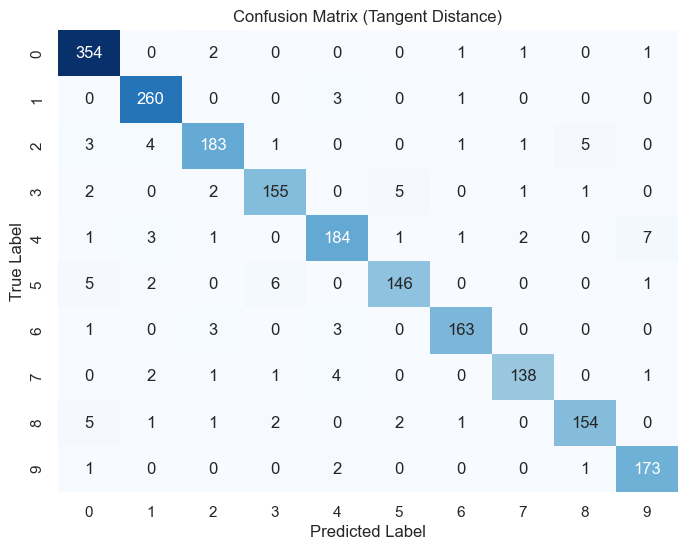

In [142]:
# Plot a confusion matrix for the:
cm_td = confusion_matrix(test_labels_np, predictions_td, labels=range(10))
plt.figure(figsize=(8, 6))
sns.heatmap(cm_td, annot=True, fmt='d', cmap="Blues", cbar=False, xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Tangent Distance)")
plt.show()
